# Pagerank - Sprawozdanie - Jakub Własiewicz

Niektóre funkcje są zdefiniowane na potrzebę podglądu, ale na wypadek są też zincludowane.

### Importy

In [1]:
include("src/pagerank.jl");
include("src/simplerank.jl");
include("src/plotting.jl")
using .simplerank
using .pagerank
using .plotting
using Karnak
using Arpack
using LinearAlgebra
using Graphs
import Graphs: pagerank as pagerank_lib

## Zadanie 1 - Prosty ranking

Ranking wierzchołka $u$ definujemy w następujący sposób:

$$ r(u) = d \sum_{v \in B_u} \frac{r(v)}{N_v}$$

Gdzie $d \in (0,1]$ jest parametrem tłumienia, $B_u$ poprzednikiami $u$, $N_v$ stopniem wyjściowym $v$.
Równanie w postaci macierzowej sprowadza się do:

$$ \textbf{r} = d \textbf{Ar} $$
$$ A_{u,v} = \begin{cases}
            \frac{1}{N_v} & \text{jeśli $(v, u) \in E$,} \\
            0 & \text{w.p.p.}\\ \end{cases}

Możemy znaleźć rozwiązanie za pomocą metody potęgowej, otrzymując wektor własny macierzy $d\textbf{A}$ odpowiadający wartości własnej $\lambda = 1$

In [2]:
function graph_simplerank(graph, d=1.0, iters=100000, ϵ=10E-30)
    @assert 0.0 < d <= 1.0
    A = matrix_A(graph) # stworzenie macierzy A z grafu
    v = power_iteration(d * A, iters, ϵ)
    v[v.<ϵ] .= 0.0 # zastąpienie wartości < ϵ zerem
    return any(v .< 0) ? -v : v # jeśli wektor jest cały ujemny, zmień znak
end

graph_simplerank (generic function with 4 methods)

### Graf Erdős–Rényi

In [3]:
n = 15
erdos = erdos_renyi(n, 1.1 * log(n) / n, is_directed=true)
while !all(outdegree(erdos) .> 0) # spójność
    erdos = erdos_renyi(n, 1.1 * log(n) / n, is_directed=true)
end
A = matrix_A(erdos)
λᵥ₁ = normalize(abs.(eigs(A)[2][:, 1]), 1) # dominujący wektor bibliotecznej funkcji
λᵥ₂ = simplerank.power_iteration(A)
λᵥ₁ - λᵥ₂ # różnica wartości wektorów własnych 

15-element Vector{Float64}:
 -1.249000902703301e-16
  8.326672684688674e-17
 -3.469446951953614e-17
  5.551115123125783e-17
  2.7755575615628914e-17
  1.1796119636642288e-16
 -1.1796119636642288e-16
 -8.326672684688674e-17
  4.163336342344337e-17
  1.6653345369377348e-16
  0.0
  1.336417669177776e-18
 -9.71445146547012e-17
  6.938893903907228e-18
 -6.938893903907228e-17

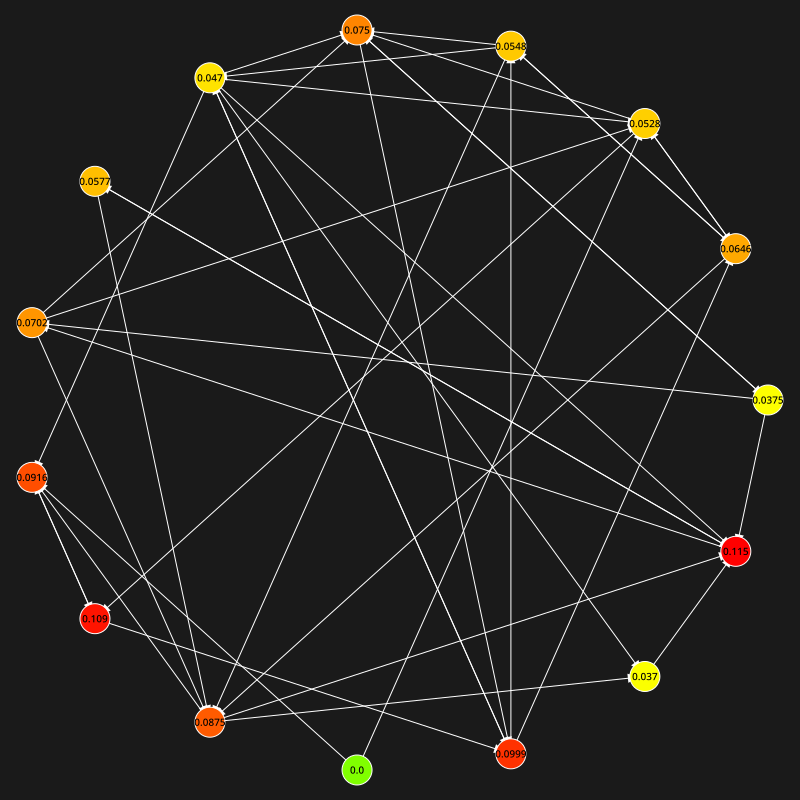

In [4]:
d = 0.85
plotting.plot_pagerank(erdos, d, simplerank.graph_simplerank, shell)

### Graf Scale-Free - Barabási–Albert Model

In [5]:
n = 15
bara = barabasi_albert(n,Int(round(n/3)), is_directed=true, complete=true)
A = matrix_A(bara)
λᵥ₁ = normalize(abs.(eigs(A)[2][:, 1]), 1) # dominujący wektor bibliotecznej funkcji
λᵥ₂ = simplerank.power_iteration(A)
λᵥ₁ - λᵥ₂ # różnica wartości wektorów własnych 

┌ Info: power iteration return because of norm < ϵ
└ @ Main.simplerank /home/hyperbarq/Documents/pagerank/src/simplerank.jl:25


15-element Vector{Float64}:
 -8.326672684688674e-17
 -1.942890293094024e-16
 -2.7755575615628914e-17
  1.1102230246251565e-16
 -5.551115123125783e-17
  8.427352498489094e-17
  1.132572671582777e-16
  2.5263322626285087e-17
  1.942281991757709e-17
  1.8045074356946127e-17
  1.1686242829345977e-17
  3.9104759270858456e-17
  4.6016533206306484e-17
  8.65174235580771e-18
  3.2210770454823e-17

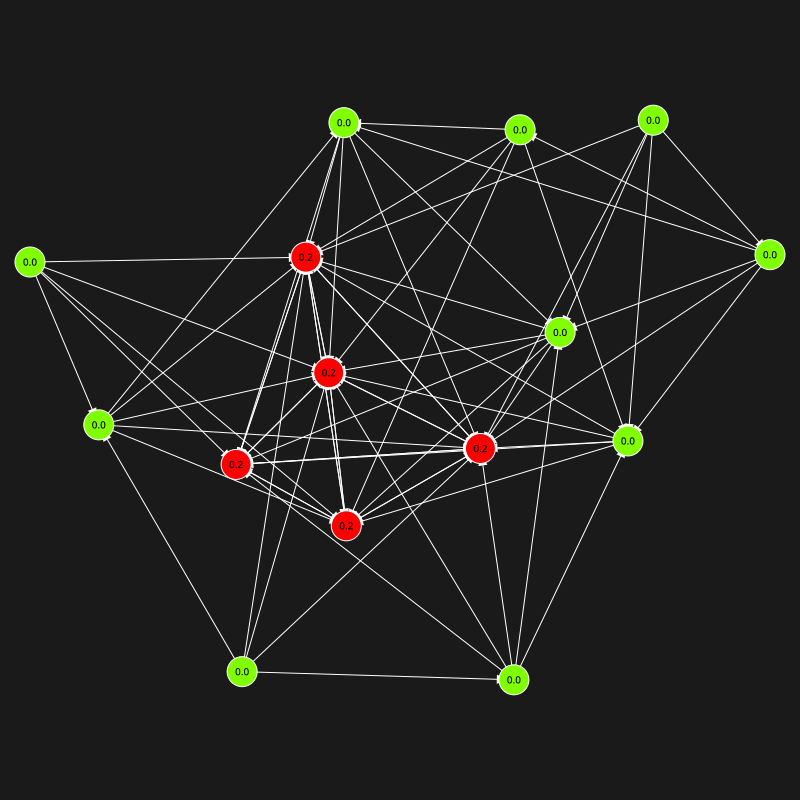

In [6]:
d = 0.85
plotting.plot_pagerank(bara, d, simplerank.graph_simplerank, stress)

### Graf Small World - Watts-Strogatz model

In [21]:
n = 15
watts_stro = watts_strogatz(n, n ÷ 2, 0.6, is_directed=true)
while !all(outdegree(watts_stro) .> 0) # spójność
    watts_stro = watts_strogatz(n, n ÷ 2, 0.6, is_directed=true)
end
A = matrix_A(watts_stro)
λᵥ₁ = normalize(abs.(eigs(A)[2][:, 1]), 1) # dominujący wektor bibliotecznej funkcji
λᵥ₂ = simplerank.power_iteration(A)
λᵥ₁ - λᵥ₂ # różnica wartości wektorów własnych

15-element Vector{Float64}:
 -1.1102230246251565e-16
 -5.551115123125783e-17
  0.0
  5.551115123125783e-17
  1.3877787807814457e-17
  3.469446951953614e-17
  7.632783294297951e-17
 -2.0816681711721685e-17
  2.7755575615628914e-17
 -1.1102230246251565e-16
  1.1102230246251565e-16
 -1.0408340855860843e-17
 -6.938893903907228e-18
  6.938893903907228e-18
  1.3877787807814457e-17

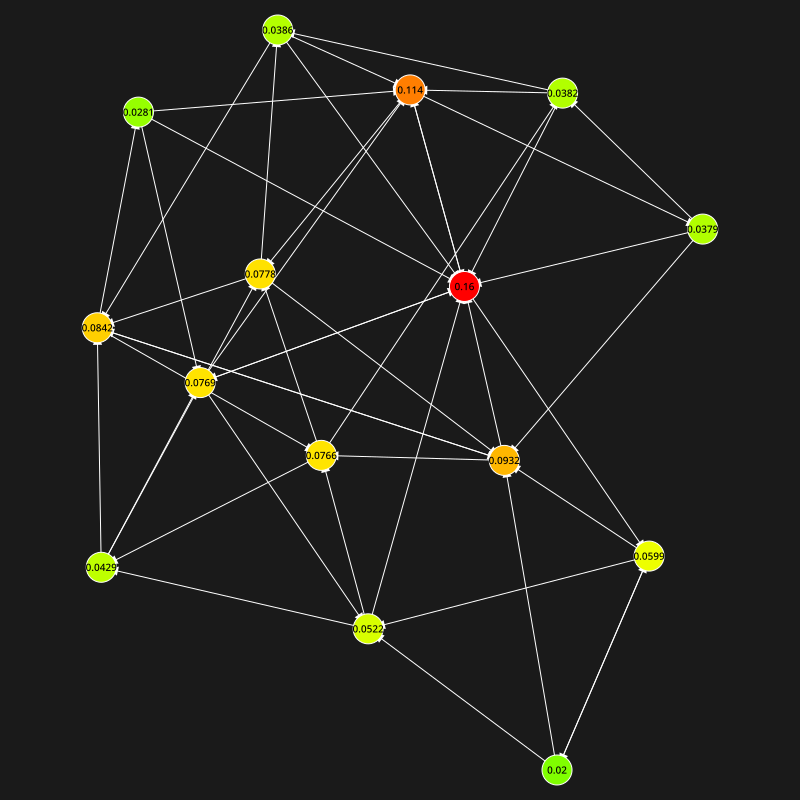

In [22]:
d = 0.85
plotting.plot_pagerank(watts_stro, d, simplerank.graph_simplerank, stress)

## Zadanie 2 - Pagerank

Tym razem mamy równanie:

$$ r(u) = d \sum_{v \in B_u} \frac{r(v)}{N_v} + (1-d)e(u)$$

Gdzie $\mathbf{e}$ jest wektorem preferencji teleportacji, oraz wprowadzimy $\hat{A}$ - macierz w których zerowe kolumny wiszących wierzchołków są zastąpione wektorem $\mathbf{e}$. $\mathbf{c}$ to wskaźnik wiszących.

$$ \hat{A} = A + \mathbf{e c}^T$$

In [ ]:
function matrix_Â(graph, e)
    A = matrix_A(graph)
    n = nv(graph)
    c = zeros(n)
    c[outdegree(graph).==0] .= 1.0
    return A + e * c'
end

Zastosujemy sprytną metodę potęgową, zamiast liczyć bezpośrednio dla macierzy $d \mathbf{A} + (1-d) \mathbf{ec}^T$ - pamięciowo $O(n^2)$

In [ ]:
function pagerank_power_iter_with_mass_re(A, d, e, ϵ) #A - macierz, d - wsp. tlum. , e - wektor teleportacji
    rᵢ = e
    rᵢ₊₁ = rᵢ
    δ = Inf
    while ϵ < δ
        rᵢ = rᵢ₊₁
        rᵢ₊₁ = d * A * rᵢ
        ρ = norm(rᵢ, 1) - norm(rᵢ₊₁, 1)
        rᵢ₊₁ += ρ * e
        δ = norm(rᵢ₊₁ - rᵢ, 1)
    end
    return rᵢ
end

Wykorzystamy znowu graf n = 15
erdos = erdos_renyi(n, 1.1 * log(n) / n, is_directed=true)Erdos-Renyi

In [ ]:
n = 15
erdos = erdos_renyi(n, 1.1 * log(n) / n, is_directed=true)